# Pipeline Klasifikasi Aksara Jawa

Pipeline ini mencakup:
1. Data Loading dan Preprocessing
2. Exploratory Data Analysis
3. CNN Pre-trained Model Training
4. Feature Extraction
5. Ensemble Model (KNN, Logistic Regression, SVC)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings('ignore')

2025-10-26 10:45:11.318319: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761475511.535653      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761475511.602958      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
print("Checking GPU availability...")
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"GPU detected: {len(gpus)} device(s)")
    for gpu in gpus:
        print(f"  - {gpu}")
    
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(f"Error setting memory growth: {e}")
    
    print(f"\nCUDA available: {tf.test.is_built_with_cuda()}")
    print(f"GPU device name: {tf.test.gpu_device_name()}")
else:
    print("No GPU detected. Running on CPU.")

print(f"\nTensorFlow version: {tf.__version__}")

Checking GPU availability...
GPU detected: 2 device(s)
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
  - PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')
GPU memory growth enabled

CUDA available: True
GPU device name: /device:GPU:0

TensorFlow version: 2.18.0


I0000 00:00:1761475626.261477      37 gpu_device.cc:2022] Created device /device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1761475626.262104      37 gpu_device.cc:2022] Created device /device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 1. Data Loading dan Preprocessing

In [4]:
train_dir = Path('/kaggle/input/aksara-jawa/v3/v3/train')
val_dir = Path('/kaggle/input/aksara-jawa/v3/v3/val')

IMG_SIZE = 128
BATCH_SIZE = 32

def load_images_from_folder(folder_path, img_size=IMG_SIZE):
    images = []
    labels = []
    
    for class_folder in sorted(folder_path.iterdir()):
        if class_folder.is_dir():
            class_name = class_folder.name
            for img_path in class_folder.glob('*'):
                if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
                    if img is not None:
                        img = cv2.resize(img, (img_size, img_size))
                        img = cv2.equalizeHist(img)
                        img = cv2.GaussianBlur(img, (3, 3), 0)
                        img = img / 255.0
                        images.append(img)
                        labels.append(class_name)
    
    return np.array(images), np.array(labels)

print("Loading training data...")
X_train, y_train = load_images_from_folder(train_dir)
print(f"Training data: {X_train.shape}")

print("Loading validation data...")
X_val, y_val = load_images_from_folder(val_dir)
print(f"Validation data: {X_val.shape}")

X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)

num_classes = len(label_encoder.classes_)
print(f"\nNumber of classes: {num_classes}")
print(f"Classes: {label_encoder.classes_}")

Loading training data...
Training data: (2154, 128, 128)
Loading validation data...
Validation data: (480, 128, 128)

Number of classes: 20
Classes: ['ba' 'ca' 'da' 'dha' 'ga' 'ha' 'ja' 'ka' 'la' 'ma' 'na' 'nga' 'nya' 'pa'
 'ra' 'sa' 'ta' 'tha' 'wa' 'ya']


## 2. Exploratory Data Analysis

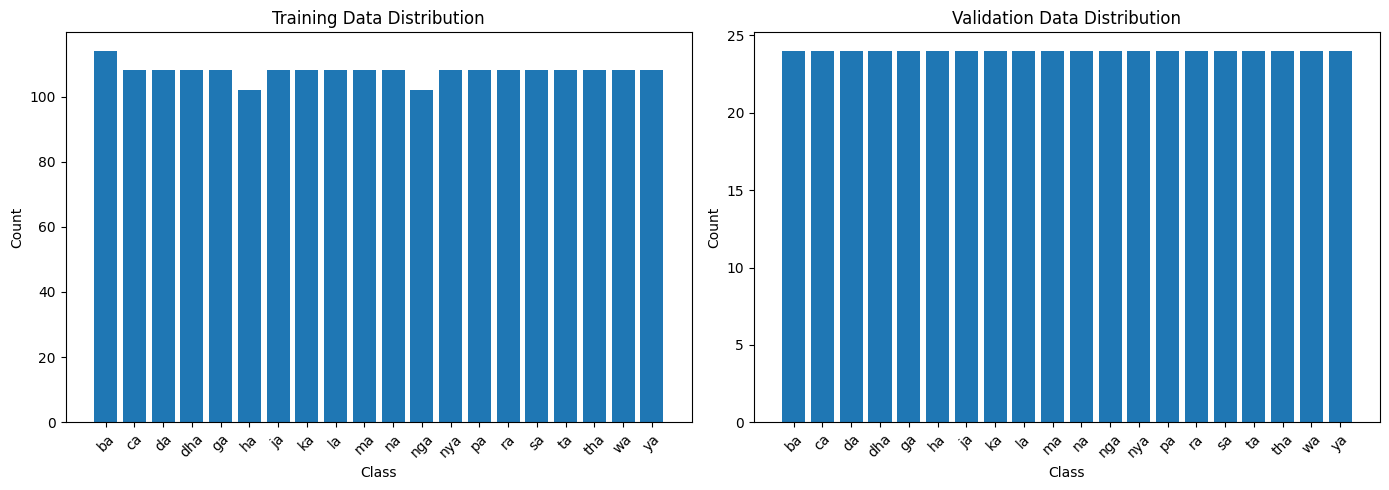


Training data distribution:
ba     114
ca     108
da     108
dha    108
ga     108
ha     102
ja     108
ka     108
la     108
ma     108
na     108
nga    102
nya    108
pa     108
ra     108
sa     108
ta     108
tha    108
wa     108
ya     108
Name: count, dtype: int64

Mean: 107.70, Std: 2.36

Validation data distribution:
ba     24
ca     24
da     24
dha    24
ga     24
ha     24
ja     24
ka     24
la     24
ma     24
na     24
nga    24
nya    24
pa     24
ra     24
sa     24
ta     24
tha    24
wa     24
ya     24
Name: count, dtype: int64

Mean: 24.00, Std: 0.00


In [5]:
train_counts = pd.Series(y_train).value_counts().sort_index()
val_counts = pd.Series(y_val).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(train_counts.index, train_counts.values)
axes[0].set_title('Training Data Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(val_counts.index, val_counts.values)
axes[1].set_title('Validation Data Distribution')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nTraining data distribution:")
print(train_counts)
print(f"\nMean: {train_counts.mean():.2f}, Std: {train_counts.std():.2f}")

print("\nValidation data distribution:")
print(val_counts)
print(f"\nMean: {val_counts.mean():.2f}, Std: {val_counts.std():.2f}")

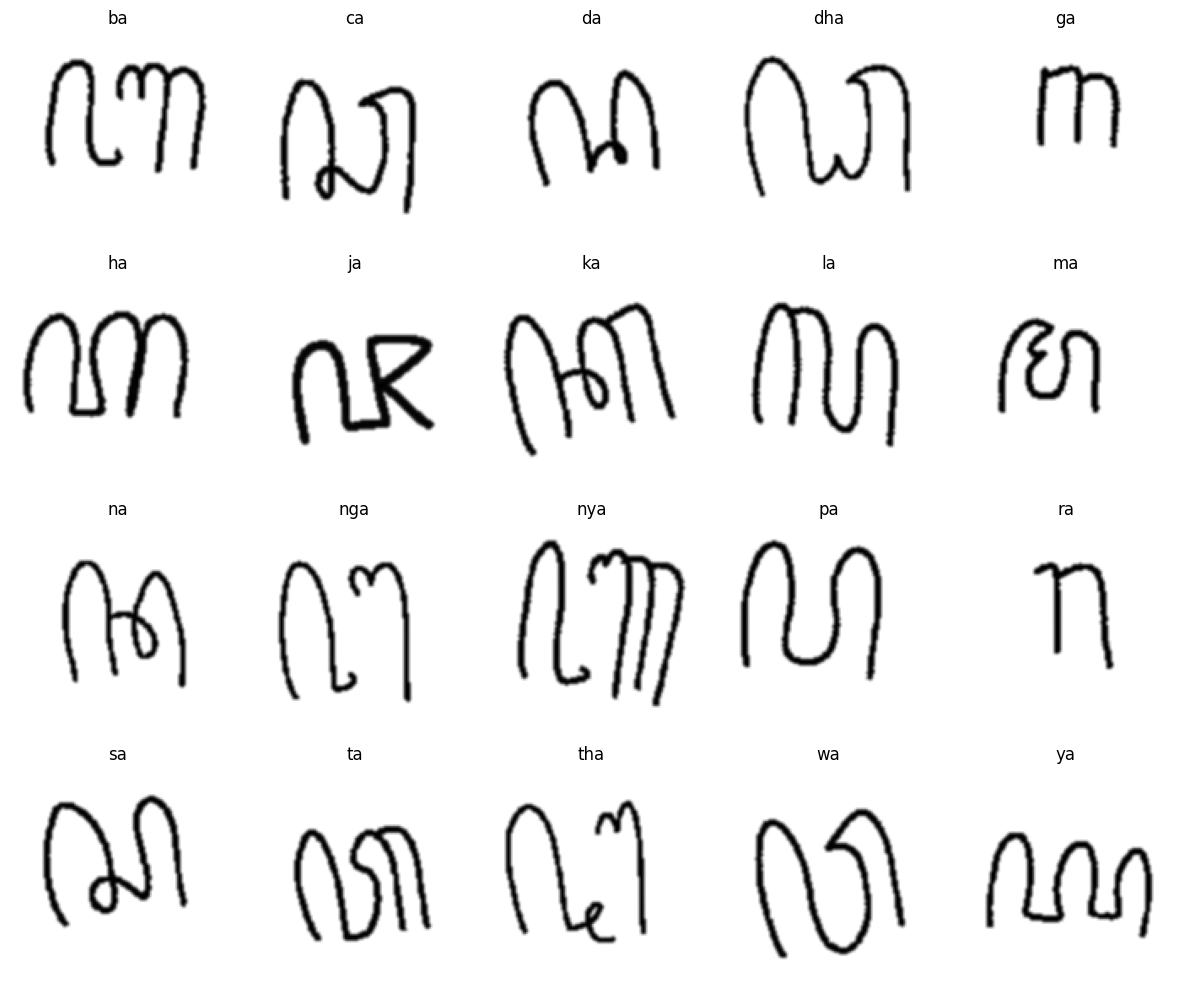

In [6]:
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
axes = axes.ravel()

for idx, class_name in enumerate(label_encoder.classes_):
    class_indices = np.where(y_train == class_name)[0]
    sample_idx = class_indices[0]
    axes[idx].imshow(X_train[sample_idx].squeeze(), cmap='gray')
    axes[idx].set_title(class_name)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 3. CNN Pre-trained Model Training

In [7]:
X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_val_rgb = np.repeat(X_val, 3, axis=-1)

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1
)
datagen.fit(X_train_rgb)

In [8]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

I0000 00:00:1761475833.031960      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1761475833.032240      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,621,396 (10.00 MB)

 Trainable params: 363,412 (1.39 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [9]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

history = model.fit(
    datagen.flow(X_train_rgb, y_train_encoded, batch_size=BATCH_SIZE),
    validation_data=(X_val_rgb, y_val_encoded),
    epochs=50,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/50


I0000 00:00:1761475928.856934      91 service.cc:148] XLA service 0x7b00c00016f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761475928.857916      91 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1761475928.857947      91 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1761475929.753953      91 cuda_dnn.cc:529] Loaded cuDNN version 90300


 3/68 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.0451 - loss: 4.0288  

I0000 00:00:1761475934.158160      91 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


68/68 ━━━━━━━━━━━━━━━━━━━━ 27s 218ms/step - accuracy: 0.1357 - loss: 3.0230 - val_accuracy: 0.4771 - val_loss: 1.8444 - learning_rate: 0.0010
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - accuracy: 0.3658 - loss: 1.9157 - val_accuracy: 0.6625 - val_loss: 1.1484 - learning_rate: 0.0010
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - accuracy: 0.5230 - loss: 1.3661 - val_accuracy: 0.6979 - val_loss: 0.9255 - learning_rate: 0.0010
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - accuracy: 0.6059 - loss: 1.0994 - val_accuracy: 0.7396 - val_loss: 0.8594 - learning_rate: 0.0010
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - accuracy: 0.6687 - loss: 0.9423 - val_accuracy: 0.7500 - val_loss: 0.6907 - learning_rate: 0.0010
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.7291 - loss: 0.7833 - val_accuracy: 0.7771 - val_loss: 0.6625 - learning_rate: 0.0010
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - accuracy: 0.7490 - loss: 0.7015 - val_accura

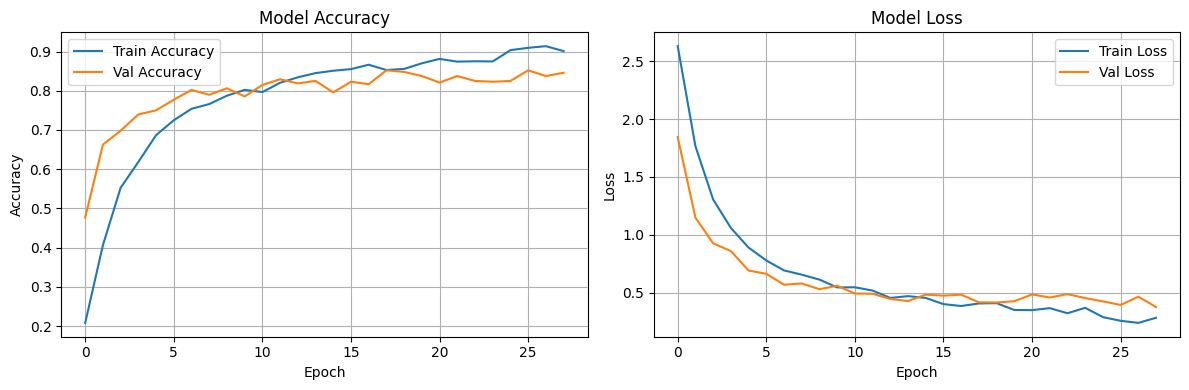


Validation Accuracy: 0.8521
Validation Loss: 0.4159


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

val_loss, val_accuracy = model.evaluate(X_val_rgb, y_val_encoded, verbose=0)
print(f"\nValidation Accuracy: {val_accuracy:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

## 4. Feature Extraction

In [ ]:
feature_extractor = models.Sequential(model.layers[:-1])

print("Extracting features from training data...")
X_train_features = feature_extractor.predict(X_train_rgb, batch_size=BATCH_SIZE, verbose=1)

print("Extracting features from validation data...")
X_val_features = feature_extractor.predict(X_val_rgb, batch_size=BATCH_SIZE, verbose=1)

print(f"\nTraining features shape: {X_train_features.shape}")
print(f"Validation features shape: {X_val_features.shape}")

AttributeError: The layer sequential has never been called and thus has no defined input.

## 5. Ensemble Model Training

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
X_train_features_scaled = scaler.fit_transform(X_train_features)
X_val_features_scaled = scaler.transform(X_val_features)

print("Training KNN Classifier...")
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_features_scaled, y_train_encoded)
knn_pred = knn.predict(X_val_features_scaled)
knn_accuracy = accuracy_score(y_val_encoded, knn_pred)
print(f"KNN Accuracy: {knn_accuracy:.4f}")

print("\nTraining Logistic Regression...")
lr = LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42)
lr.fit(X_train_features_scaled, y_train_encoded)
lr_pred = lr.predict(X_val_features_scaled)
lr_accuracy = accuracy_score(y_val_encoded, lr_pred)
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

print("\nTraining SVC...")
svc = SVC(kernel='rbf', probability=True, random_state=42)
svc.fit(X_train_features_scaled, y_train_encoded)
svc_pred = svc.predict(X_val_features_scaled)
svc_accuracy = accuracy_score(y_val_encoded, svc_pred)
print(f"SVC Accuracy: {svc_accuracy:.4f}")

print("\nTraining Random Forest...")
rf = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf.fit(X_train_features, y_train_encoded)
rf_pred = rf.predict(X_val_features)
rf_accuracy = accuracy_score(y_val_encoded, rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

print("\nTraining Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
gb.fit(X_train_features, y_train_encoded)
gb_pred = gb.predict(X_val_features)
gb_accuracy = accuracy_score(y_val_encoded, gb_pred)
print(f"Gradient Boosting Accuracy: {gb_accuracy:.4f}")

print("\nTraining XGBoost...")
xgb = XGBClassifier(n_estimators=200, max_depth=7, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb.fit(X_train_features, y_train_encoded)
xgb_pred = xgb.predict(X_val_features)
xgb_accuracy = accuracy_score(y_val_encoded, xgb_pred)
print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")

print("\nTraining AdaBoost...")
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train_features, y_train_encoded)
ada_pred = ada.predict(X_val_features)
ada_accuracy = accuracy_score(y_val_encoded, ada_pred)
print(f"AdaBoost Accuracy: {ada_accuracy:.4f}")

print("\nTraining Naive Bayes...")
nb = GaussianNB()
nb.fit(X_train_features_scaled, y_train_encoded)
nb_pred = nb.predict(X_val_features_scaled)
nb_accuracy = accuracy_score(y_val_encoded, nb_pred)
print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}")

In [ ]:
print("Training Voting Classifier (Soft Voting)...")
voting_clf = VotingClassifier(
    estimators=[
        ('knn', knn),
        ('lr', lr),
        ('svc', svc),
        ('rf', rf),
        ('xgb', xgb),
        ('nb', nb)
    ],
    voting='soft',
    n_jobs=-1
)

voting_clf.fit(X_train_features_scaled, y_train_encoded)
voting_pred = voting_clf.predict(X_val_features_scaled)
voting_accuracy = accuracy_score(y_val_encoded, voting_pred)

print(f"\nVoting Ensemble Accuracy: {voting_accuracy:.4f}")

print("\n" + "="*60)
print("Model Comparison:")
print("="*60)
print(f"KNN:                  {knn_accuracy:.4f}")
print(f"Logistic Regression:  {lr_accuracy:.4f}")
print(f"SVC:                  {svc_accuracy:.4f}")
print(f"Random Forest:        {rf_accuracy:.4f}")
print(f"Gradient Boosting:    {gb_accuracy:.4f}")
print(f"XGBoost:              {xgb_accuracy:.4f}")
print(f"AdaBoost:             {ada_accuracy:.4f}")
print(f"Naive Bayes:          {nb_accuracy:.4f}")
print(f"Voting Ensemble:      {voting_accuracy:.4f}")
print("="*60)

best_model_name = max([
    ('KNN', knn_accuracy),
    ('Logistic Regression', lr_accuracy),
    ('SVC', svc_accuracy),
    ('Random Forest', rf_accuracy),
    ('Gradient Boosting', gb_accuracy),
    ('XGBoost', xgb_accuracy),
    ('AdaBoost', ada_accuracy),
    ('Naive Bayes', nb_accuracy),
    ('Voting Ensemble', voting_accuracy)
], key=lambda x: x[1])

print(f"\nBest Model: {best_model_name[0]} with accuracy {best_model_name[1]:.4f}")

## 6. Evaluation

In [ ]:
print("Classification Report for Voting Ensemble:")
print(classification_report(y_val_encoded, voting_pred, 
                          target_names=label_encoder.classes_))

In [ ]:
cm = confusion_matrix(y_val_encoded, voting_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Voting Ensemble')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
accuracies = {
    'KNN': knn_accuracy,
    'Logistic\nRegression': lr_accuracy,
    'SVC': svc_accuracy,
    'Random\nForest': rf_accuracy,
    'Gradient\nBoosting': gb_accuracy,
    'XGBoost': xgb_accuracy,
    'AdaBoost': ada_accuracy,
    'Naive\nBayes': nb_accuracy,
    'Voting\nEnsemble': voting_accuracy
}

plt.figure(figsize=(14, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#17becf']
bars = plt.bar(accuracies.keys(), accuracies.values(), color=colors)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
results_df = pd.DataFrame({
    'Model': ['KNN', 'Logistic Regression', 'SVC', 'Random Forest', 
              'Gradient Boosting', 'XGBoost', 'AdaBoost', 'Naive Bayes', 'Voting Ensemble'],
    'Accuracy': [knn_accuracy, lr_accuracy, svc_accuracy, rf_accuracy, 
                 gb_accuracy, xgb_accuracy, ada_accuracy, nb_accuracy, voting_accuracy]
})

results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df['Rank'] = range(1, len(results_df) + 1)

print("\nModel Performance Ranking:")
print("="*50)
print(results_df.to_string(index=False))
print("="*50)